Fraud train/test: (800, 34) (200, 34)
Fraud train class balance:
 fraud_label
0    0.7525
1    0.2475
Name: proportion, dtype: float64

Encoded shape - train: (800, 130) test: (200, 130)

--- insured_hobbies fraud rate check ---
insured_hobbies
chess           0.826087
cross-fit       0.742857
yachting        0.301887
board-games     0.291667
polo            0.276596
reading         0.265625
base-jumping    0.265306
hiking          0.230769
paintball       0.228070
skydiving       0.224490
Name: fraud_label, dtype: float64

========== LOGISTIC REGRESSION (Baseline) ==========


c:\Users\singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.78      0.49      0.60       151
       Fraud       0.27      0.57      0.36        49

    accuracy                           0.51       200
   macro avg       0.52      0.53      0.48       200
weighted avg       0.65      0.51      0.54       200

ROC-AUC:          0.5993
PR-AUC:           0.3018


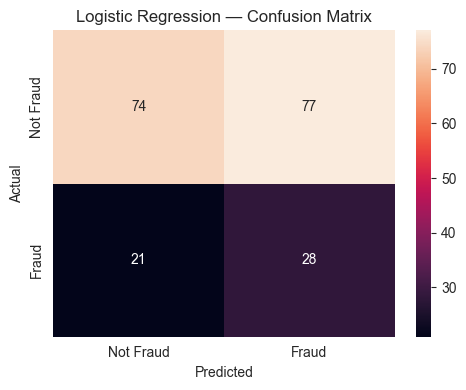


========== XGBOOST (class_weight imbalance handling) ==========
scale_pos_weight = 3.04  (neg/pos ratio)

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.88      0.85      0.86       151
       Fraud       0.57      0.63      0.60        49

    accuracy                           0.80       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.80      0.80      0.80       200

ROC-AUC:          0.8325
PR-AUC:           0.5887


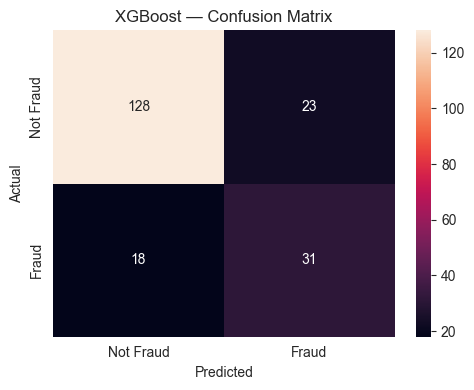


========== XGBOOST + SMOTE ==========
After SMOTE — train size: 1204, class balance: 0.50

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.88      0.89      0.88       151
       Fraud       0.64      0.61      0.62        49

    accuracy                           0.82       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.82      0.82      0.82       200

ROC-AUC:          0.8434
PR-AUC:           0.6122


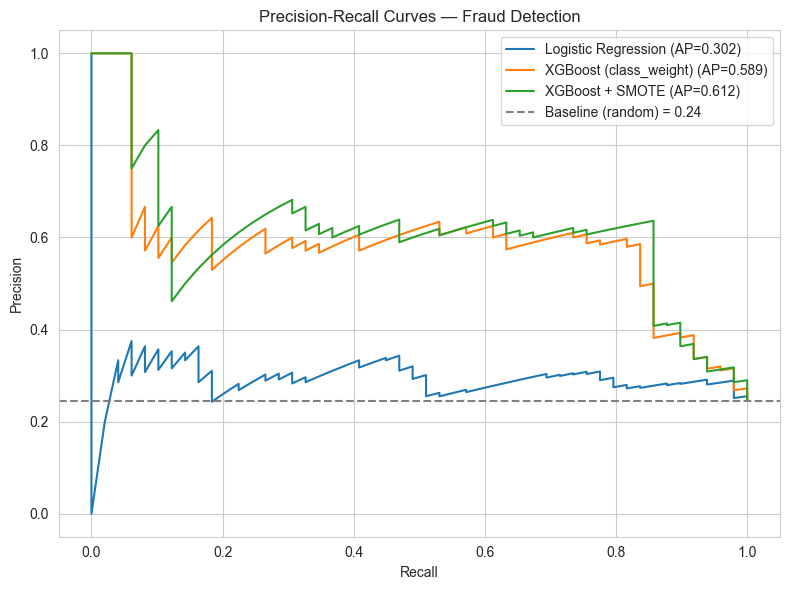


========== ISOLATION FOREST (unsupervised cross-check) ==========

Isolation Forest Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.72      0.67      0.69       151
       Fraud       0.17      0.20      0.18        49

    accuracy                           0.56       200
   macro avg       0.44      0.44      0.44       200
weighted avg       0.59      0.56      0.57       200


Cases flagged as fraud by BOTH models:
  Total: 14
  Actual fraud among these: 42.9%

Cases flagged by NEITHER model:
  Total: 100
  Actual fraud among these (missed): 14.0%

--- XGBoost Feature Importances (top 20) ---
cat__incident_severity_Major Damage                 0.095626
cat__insured_hobbies_chess                          0.066256
cat__insured_hobbies_cross-fit                      0.062742
cat__incident_city_Riverwood                        0.017594
cat__severity_vehicle_interaction_Major Damage_0    0.015422
cat__insured_hobbies_polo              

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
%matplotlib inline

# ============================================================
# LOAD & CLEAN (same as all previous files)
# ============================================================
df = pd.read_csv('insurance_claims.csv')

if '_c39' in df.columns:
    df = df.drop(columns=['_c39'])

df = df.replace('?', np.nan)
df['fraud_label'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

# ============================================================
# FEATURE ENGINEERING (same as 02)
# ============================================================
drop_cols = ['policy_number', 'policy_bind_date', 'insured_zip', 'incident_date',
             'incident_location', 'auto_model']
df_fe = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in ['collision_type', 'authorities_contacted', 'property_damage', 'police_report_available']:
    df_fe[col] = df_fe[col].fillna('Unknown')

df_fe['multi_vehicle_incident'] = (df_fe['number_of_vehicles_involved'] >= 2).astype(int)
df_fe['severity_vehicle_interaction'] = (
    df_fe['incident_severity'].astype(str) + "_" + df_fe['multi_vehicle_incident'].astype(str)
)

fraud_leakage_cols = ['fraud_reported', 'fraud_label']
X_fraud = df_fe.drop(columns=[c for c in fraud_leakage_cols if c in df_fe.columns])
y_fraud = df_fe['fraud_label']

# ============================================================
# TRAIN/TEST SPLIT
# ============================================================
X_frd_train, X_frd_test, y_frd_train, y_frd_test = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud
)

print("Fraud train/test:", X_frd_train.shape, X_frd_test.shape)
print("Fraud train class balance:\n", y_frd_train.value_counts(normalize=True))

# ============================================================
# ENCODING
# ============================================================
cat_cols = X_frd_train.select_dtypes(include='object').columns.tolist()
num_cols = X_frd_train.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

X_frd_train_enc = preprocessor.fit_transform(X_frd_train)
X_frd_test_enc = preprocessor.transform(X_frd_test)

print("\nEncoded shape - train:", X_frd_train_enc.shape, "test:", X_frd_test_enc.shape)

# ============================================================
# DATASET ARTIFACT CHECK: insured_hobbies
# This dataset has a known synthetic quirk where certain hobby
# values (chess, cross-fit) are near-deterministically tied to
# fraud — not a real-world pattern. We test with and without it.
# ============================================================
print("\n--- insured_hobbies fraud rate check ---")
print(df_fe.groupby('insured_hobbies')['fraud_label'].mean().sort_values(ascending=False).head(10))

# ============================================================
# MODEL 1: LOGISTIC REGRESSION (baseline)
# ============================================================
print("\n========== LOGISTIC REGRESSION (Baseline) ==========")

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_frd_train_enc, y_frd_train)
lr_preds = lr_model.predict(X_frd_test_enc)
lr_proba = lr_model.predict_proba(X_frd_test_enc)[:, 1]

print("\nClassification Report:")
print(classification_report(y_frd_test, lr_preds, target_names=['Not Fraud', 'Fraud']))
print(f"ROC-AUC:          {roc_auc_score(y_frd_test, lr_proba):.4f}")
print(f"PR-AUC:           {average_precision_score(y_frd_test, lr_proba):.4f}")

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_frd_test, lr_preds), annot=True, fmt='d',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=100)
plt.show()
plt.close()

# ============================================================
# MODEL 2: XGBOOST — with class_weight (scale_pos_weight)
# ============================================================
print("\n========== XGBOOST (class_weight imbalance handling) ==========")

neg_count = (y_frd_train == 0).sum()
pos_count = (y_frd_train == 1).sum()
scale_pos = neg_count / pos_count
print(f"scale_pos_weight = {scale_pos:.2f}  (neg/pos ratio)")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_frd_train_enc, y_frd_train)
xgb_preds = xgb_model.predict(X_frd_test_enc)
xgb_proba = xgb_model.predict_proba(X_frd_test_enc)[:, 1]

print("\nClassification Report:")
print(classification_report(y_frd_test, xgb_preds, target_names=['Not Fraud', 'Fraud']))
print(f"ROC-AUC:          {roc_auc_score(y_frd_test, xgb_proba):.4f}")
print(f"PR-AUC:           {average_precision_score(y_frd_test, xgb_proba):.4f}")

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_frd_test, xgb_preds), annot=True, fmt='d',
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=100)
plt.show()
plt.close()

# ============================================================
# MODEL 3: XGBOOST + SMOTE (alternative imbalance strategy)
# ============================================================
print("\n========== XGBOOST + SMOTE ==========")

smote = SMOTE(random_state=42)
X_frd_train_sm, y_frd_train_sm = smote.fit_resample(X_frd_train_enc, y_frd_train)
print(f"After SMOTE — train size: {X_frd_train_sm.shape[0]}, class balance: {y_frd_train_sm.mean():.2f}")

xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)
xgb_smote.fit(X_frd_train_sm, y_frd_train_sm)
xgb_smote_preds = xgb_smote.predict(X_frd_test_enc)
xgb_smote_proba = xgb_smote.predict_proba(X_frd_test_enc)[:, 1]

print("\nClassification Report:")
print(classification_report(y_frd_test, xgb_smote_preds, target_names=['Not Fraud', 'Fraud']))
print(f"ROC-AUC:          {roc_auc_score(y_frd_test, xgb_smote_proba):.4f}")
print(f"PR-AUC:           {average_precision_score(y_frd_test, xgb_smote_proba):.4f}")

# ============================================================
# PRECISION-RECALL CURVE (all supervised models)
# ============================================================
plt.figure(figsize=(8, 6))
for name, proba in [('Logistic Regression', lr_proba),
                     ('XGBoost (class_weight)', xgb_proba),
                     ('XGBoost + SMOTE', xgb_smote_proba)]:
    precision, recall, _ = precision_recall_curve(y_frd_test, proba)
    ap = average_precision_score(y_frd_test, proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')

plt.axhline(y_frd_test.mean(), color='grey', linestyle='--', label=f'Baseline (random) = {y_frd_test.mean():.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Fraud Detection')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=100)
plt.show()
plt.close()

# ============================================================
# MODEL 4: ISOLATION FOREST (unsupervised cross-check)
# "Do anomaly-based and supervised approaches agree?"
# ============================================================
print("\n========== ISOLATION FOREST (unsupervised cross-check) ==========")

iso = IsolationForest(contamination=pos_count / len(y_frd_train), random_state=42)
iso.fit(X_frd_train_enc)

# IsolationForest predicts -1 (anomaly) or 1 (normal) — remap to 1/0 fraud labels
iso_raw = iso.predict(X_frd_test_enc)
iso_preds = np.where(iso_raw == -1, 1, 0)

print("\nIsolation Forest Classification Report:")
print(classification_report(y_frd_test, iso_preds, target_names=['Not Fraud', 'Fraud']))

# Agreement analysis: where do supervised and unsupervised agree?
agreement_df = pd.DataFrame({
    'actual': y_frd_test.values,
    'xgb_pred': xgb_preds,
    'iso_pred': iso_preds
})
agreement_df['both_flag_fraud'] = ((agreement_df['xgb_pred'] == 1) & (agreement_df['iso_pred'] == 1)).astype(int)
agreement_df['neither_flags'] = ((agreement_df['xgb_pred'] == 0) & (agreement_df['iso_pred'] == 0)).astype(int)

print("\nCases flagged as fraud by BOTH models:")
print(f"  Total: {agreement_df['both_flag_fraud'].sum()}")
print(f"  Actual fraud among these: {agreement_df[agreement_df['both_flag_fraud']==1]['actual'].mean():.1%}")

print("\nCases flagged by NEITHER model:")
print(f"  Total: {agreement_df['neither_flags'].sum()}")
print(f"  Actual fraud among these (missed): {agreement_df[agreement_df['neither_flags']==1]['actual'].mean():.1%}")

# ============================================================
# FEATURE IMPORTANCE: does insured_hobbies dominate?
# ============================================================
print("\n--- XGBoost Feature Importances (top 20) ---")
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances.head(20))

hobby_importance = importances[importances.index.str.contains('hobbies')].sum()
total_importance = importances.sum()
print(f"\nTotal importance from insured_hobbies columns: {hobby_importance:.4f} ({hobby_importance/total_importance:.1%} of total)")

# ============================================================
# COMPARISON SUMMARY TABLE
# ============================================================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost (class_weight)', 'XGBoost + SMOTE', 'Isolation Forest'],
    'PR-AUC': [
        average_precision_score(y_frd_test, lr_proba),
        average_precision_score(y_frd_test, xgb_proba),
        average_precision_score(y_frd_test, xgb_smote_proba),
        np.nan  # unsupervised, no probability output
    ],
    'ROC-AUC': [
        roc_auc_score(y_frd_test, lr_proba),
        roc_auc_score(y_frd_test, xgb_proba),
        roc_auc_score(y_frd_test, xgb_smote_proba),
        np.nan
    ],
    'F1 (Fraud)': [
        f1_score(y_frd_test, lr_preds),
        f1_score(y_frd_test, xgb_preds),
        f1_score(y_frd_test, xgb_smote_preds),
        f1_score(y_frd_test, iso_preds)
    ]
})
print("\n=== Final Model Comparison ===")
print(results.to_string(index=False))